In [1]:
# !pip install ncmcm

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from ncmcm.data_loaders.matlab_dataset import Database
from ncmcm.visualisers.neuronal_behavioural import plotting_neuronal_behavioural
from ncmcm.cognitive_graphs.cognitive_graphs import behavioral_state_diagram
from sklearn.ensemble import RandomForestClassifier
from ncmcm.cognitive_graphs.cognitive_graphs import cluster_neural_activity
from ncmcm.statistical_testing.markov import *
from IPython.display import HTML
import os

## Load Data (excluding behavioural neurons)

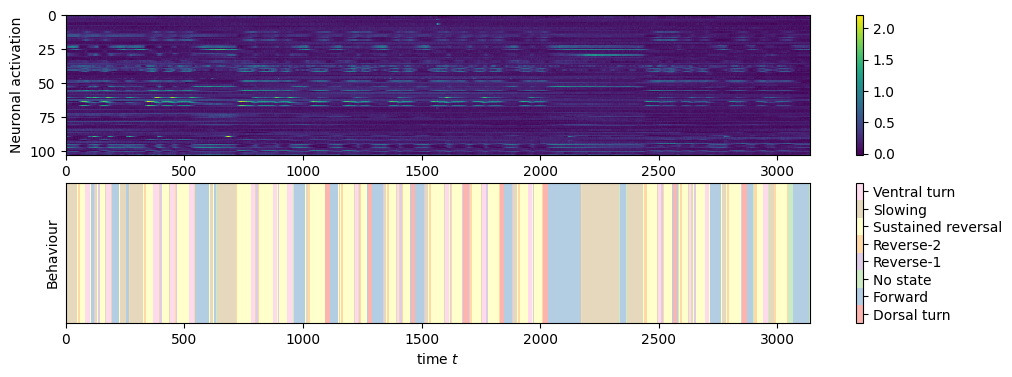

(<Figure size 1200x400 with 4 Axes>,
 array([<Axes: xlabel='time $t$', ylabel='Neuronal activation'>,
        <Axes: xlabel='time $t$', ylabel='Behaviour'>], dtype=object))

In [2]:
worm_num = 0
b_neurons = [
    'AVAR',
    'AVAL',
    'SMDVR',
    'SMDVL',
    'SMDDR',
    'SMDDL',
    'RIBR',
    'RIBL'
]
data_path = '../datasets/raw/c_elegans/NoStim_Data.mat'
data = Database(data_path=data_path, dataset_no=worm_num)
data.exclude_neurons(b_neurons)
x = data.neuron_traces.T
b = data.behaviour
behaviors = list(data.behaviour_names.values())
os.chdir('..')

plotting_neuronal_behavioural(x, b, b_names=data.behaviour_names)

## Get cognitive state sequence by clustering behavioral probability trajectories (BPT)

In [3]:
# This method allows for a lot of customisability, with only the first 3 parameters being required
# For the model parameter each classifier with the methods: predict, predict_proba and fit works fine
cognitive_states = cluster_neural_activity(N=x.T, 
                                           B=b.astype(int),
                                           n_clusters=3,
                                           nrep=5,
                                           ensemble=True,
                                           sim_m=500,
                                           sim_s=500,
                                           chunks=0,
                                           clustering='kmeans',
                                           kmeans_init='auto',
                                           stationary=True,
                                           model=RandomForestClassifier(n_estimators=20, # we use a RandomForest
                                                                        random_state=42))
# Use the cognitive state sequence with the best p-values
# The 'nrep's are sorted by p-value, best p-values for markov process are first
# Each tuple in the list contains (the sequence, p-value markov property, p-value stationary property (optional))
c_best = cognitive_states[0][0]

Accuracy for full training data: 0.9993624481989162
Testing markovianity for 3 clusters - repetition 1
Testing markovianity for 3 clusters - repetition 2
Testing markovianity for 3 clusters - repetition 3
Testing markovianity for 3 clusters - repetition 4
Testing markovianity for 3 clusters - repetition 5


## Plot the cognitive graph

['Dorsal turn', 'Forward', 'No state', 'Reverse-1', 'Reverse-2', 'Sustained reversal', 'Slowing', 'Ventral turn']


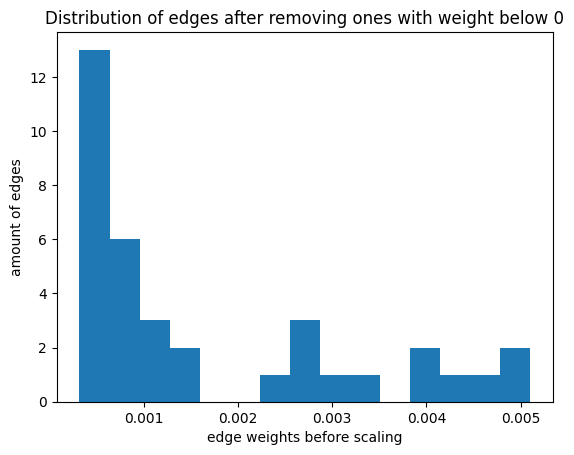

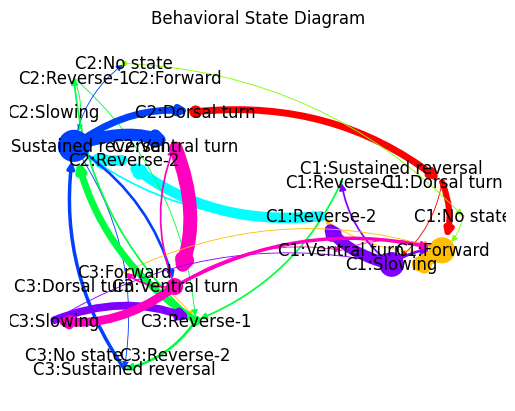

In [4]:
# First we plot the diagram with all edges by setting threshold to 0. Using the weight_hist we see 
# the distribution in edge thickness
result = behavioral_state_diagram(c_best, b, behaviors=behaviors,
                                  weights_hist=True,
                                  bins=15,
                                  threshold=0)

['Dorsal turn', 'Forward', 'No state', 'Reverse-1', 'Reverse-2', 'Sustained reversal', 'Slowing', 'Ventral turn']


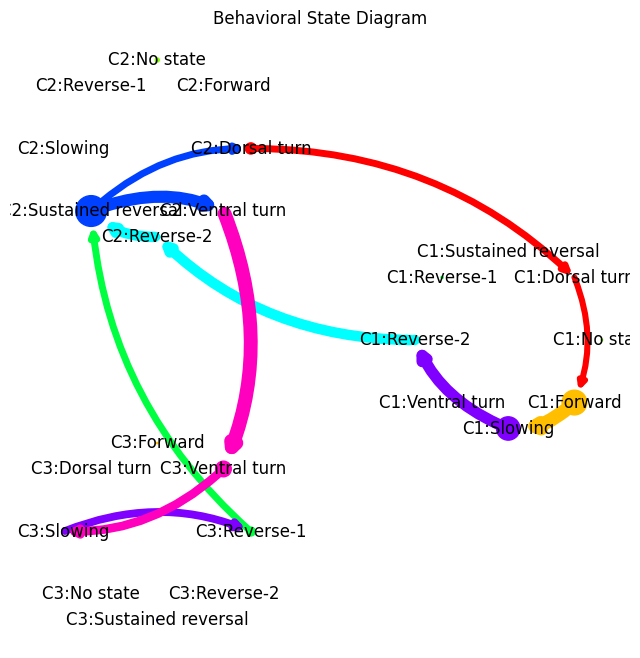

['Dorsal turn', 'Forward', 'No state', 'Reverse-1', 'Reverse-2', 'Sustained reversal', 'Slowing', 'Ventral turn']
Calculated threshold is:  0.000510204081632653


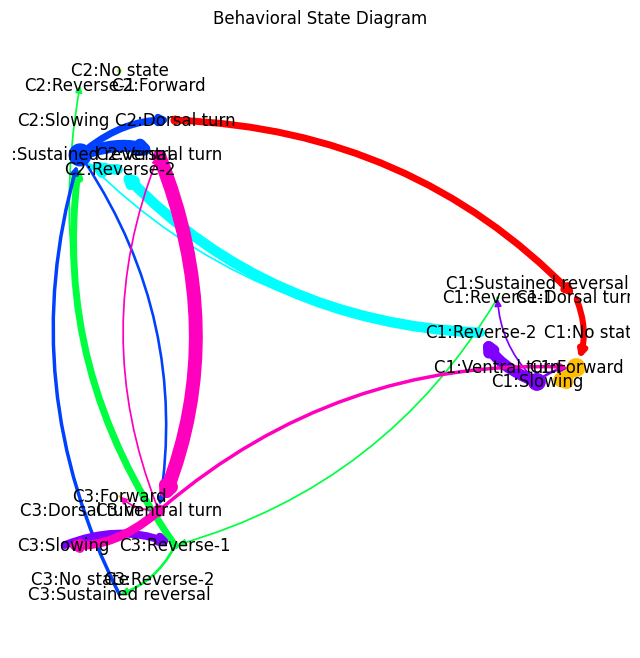

True

In [5]:
# Using these insights we can either let the algorithm decide where to put the cut-off or decide our self.
# We can also define a offset, this will change the spacing between clusters.
behavioral_state_diagram(c_best, b, 
                         behaviors=behaviors,
                         threshold=0.002,
                         figsize=(8, 8))
behavioral_state_diagram(c_best, b, 
                         behaviors=behaviors,
                         offset=5,
                         figsize=(8, 8))

['Dorsal turn', 'Forward', 'No state', 'Reverse-1', 'Reverse-2', 'Sustained reversal', 'Slowing', 'Ventral turn']
Calculated threshold is:  0.000510204081632653


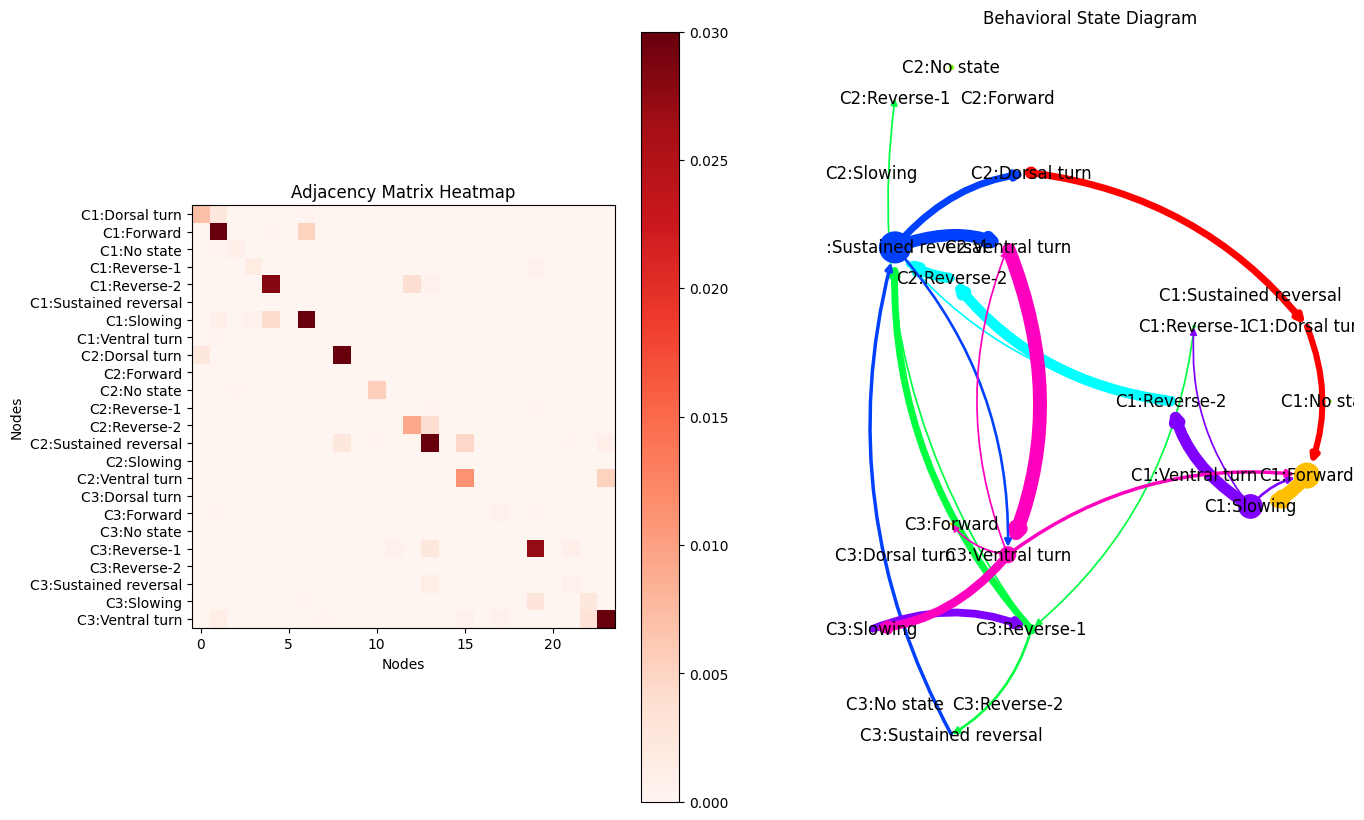

True

In [6]:
# Next we also plot the adjacency matrix
behavioral_state_diagram(c_best, b, 
                         behaviors=behaviors,
                         adj_matrix=True,
                         figsize=(15, 10))

## Interactive plots (using pyvis)

In [7]:
behavioral_state_diagram(c_best, b, 
                         behaviors=behaviors,
                         interactive='figures/Interactive_graph')

['Dorsal turn', 'Forward', 'No state', 'Reverse-1', 'Reverse-2', 'Sustained reversal', 'Slowing', 'Ventral turn']
Calculated threshold is:  0.000510204081632653
figures/test.html
Plot has been saved under: /Users/michaelhofer/Documents/GitHub/UniProject/figures/test.html


True

In [8]:
# Here we display the HTML-file, however accessing by browser allows for a better user-experience
HTML(filename="figures/Interactive_graph.html")

## Statistical tests

In [ ]:
# Simulate some sequences
seq_1, _ = simulate_markovian(M=1000, N=5, order=1)
seq_2, _ = simulate_markovian(M=1000, N=5, order=2)
seq_non_stat = non_stationary_process(M=1000, N=5)

In [11]:
# The markov property test returns the empirical 1st order transition matrix and a p-value.
# A p-value below 0.05 signals behavior not agreeable with a 1st order markov process.
p_1, P_1 = markovian(seq_1)
p_2, P_2 = markovian(seq_2)
print(f'Since {round(p_1, 3)} > 0.05, the sequence could come from a 1st order Markov process')
print(f'Since {round(p_2, 3)} < 0.05, the sequence seems not to come from a 1st order Markov process')

Since 0.981 > 0.05, the sequence could come from a 1st order Markov process
Since 0.0 < 0.05, the sequence seems not to come from a 1st order Markov process


In [14]:
# The stationary property test returns the adjusted p-value and the unadjusted p-value.
# A adjusted p-value below 0.05 signals behavior agreeable with a stationary markov process.
p_adjusted_1, p_unadjusted_1 = stationarity(seq_1, chunks=None)
p_adjusted_non_stat, p_unadjusted_non_stat = stationarity(seq_non_stat, chunks=5)
print(f'Since {round(p_adjusted_1, 3)} < 0.05, the sequence could come from a Markov process')
print(f'Since {round(p_adjusted_non_stat, 3)} > 0.05, the sequence seems not to come from a stationary Markov process')

Since 0.02 < 0.05, the sequence could come from a Markov process
Since 0.606 > 0.05, the sequence seems not to come from a stationary Markov process
